In [7]:
# If needed, install dependencies (run once per environment)
# look at README for env directions

In [6]:
import csv
import networkx as nx
import numpy as np
import pandas as pd
from node2vec import Node2Vec
import umap
import matplotlib.pyplot as plt

## 1. Load Data

In [13]:
# ---------- 1. Load data ----------

# Assumed CSVs:
# philosophers.csv: ID,Name
# philosopher_details.csv: ID,BirthYear,DeathYear,Region,Civilization/Tradition,Era,School/Movement,...
# relations.csv: ID,InfluencedByIDs,InfluencedIDs

philosophers = pd.read_csv("../data/philosophers.csv")
details = pd.read_csv("../data/details.csv")
relations = pd.read_csv("../data/relations.csv")

## 2. Build Graph

In [15]:
# ---------- 2. Build the graph from relations ----------

G = nx.Graph()

# Add all nodes (so nodes with no edges still appear)
for pid in philosophers["ID"]:
    G.add_node(pid)
# Adding edges
for _, row in relations.iterrows():
    src = row["ID"]
    if pd.isna(row["InfluencedByIDs"]):
        continue
    # Add edges based on InfluencedByIDs
    influenced_by = [x.strip() for x in str(row["InfluencedByIDs"]).split(";") if x.strip()]
    for dst in influenced_by:
        if dst in G:  # guard against typos / missing IDs
            G.add_edge(src, dst)

    # 2) From InfluencedIDs: src → successors
    if not pd.isna(row["InfluencedIDs"]):
        influenced = [
            x.strip() for x in str(row["InfluencedIDs"]).split(";") if x.strip()
        ]
        for dst in influenced:
            if dst in G and dst != src:
                G.add_edge(src, dst)

print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

Graph has 101 nodes and 234 edges


## 3. node2vec embeddings

In [26]:
# ---------- 3. node2vec embeddings ----------

node2vec = Node2Vec(
    G, 
    dimensions=16,   # Reduced for extremely small/sparse structures
    walk_length=5,    # Shortened to match the tiny graph size
    num_walks=200,    # Reduced to prevent massive oversampling
    p=2.0,            # High p encourages exploration away from the start node
    q=0.5,            # Low q forces the walk to move outward (DFS-like)
    workers=2, 
    seed=42
)

model = node2vec.fit(window=10, min_count=1, batch_words=4)

# Ensure consistent ordering of nodes
ids = sorted(G.nodes())
embeddings = np.array([model.wv[node_id] for node_id in ids])

Computing transition probabilities:   0%|          | 0/101 [00:00<?, ?it/s]

Generating walks (CPU: 2): 100%|██████████| 100/100 [00:00<00:00, 884.99it/s]


## 4. UMAP or TSNE to 2D

In [35]:
# ---------- 4. UMAP to 2D ----------
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=10,
    min_dist=0.05,
    metric="euclidean",
    init='pca',
    random_state=42
)
# umap_reducer = umap.UMAP(
#     n_neighbors=50,    # Increase this (default is 15) to pull clusters together
#     min_dist=0.00,     # Decrease this (default is 0.1) to allow tight packing
#     init='pca'         # Ensures a stable, globally organized starting layout
# )

coords = umap_reducer.fit_transform(embeddings)

coords_df = pd.DataFrame(coords, columns=["x", "y"])
coords_df["ID"] = ids

/Users/aslakey/Desktop/MapOfPhilosphy/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [79]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=12,      # try 5–20 for ~100 nodes
    learning_rate=200,
    metric="euclidean", # embeddings are in Euclidean space from node2vec
    random_state=42,
    init="random"       # or "pca" if you prefer
)

coords_tsne = tsne.fit_transform(embeddings)

coords_df = pd.DataFrame(coords_tsne, columns=["x", "y"])
coords_df["ID"] = ids


In [80]:
emb_df = pd.DataFrame({
    "ID": ids,
    "embedding": [emb.tolist() for emb in embeddings]
})

coords_with_emb = coords_df.merge(emb_df, on="ID", how="left")

In [81]:
coords_df.head()

,x,y,ID
0,37.131710,71.536385,P001
1,43.810429,61.823994,P002
2,34.841084,23.810022,P003
3,34.736912,32.200085,P004
4,77.292824,18.437359,P005


## 5. Plotting and coloring by themes

In [82]:
# Join with metadata
meta = details.merge(philosophers, on="ID", how="left")  # adds Name
coords_meta = coords_df.merge(meta, on="ID", how="left")

In [83]:
coords_meta.head()

,x,y,ID,BirthYear,DeathYear,Region,Civilization/Tradition,Era,School/Movement,CoreTeachings,HistoricalContext,PrimaryTopics,MetaphysicalStance,EpistemologicalStance,EthicalOrientation,PoliticalOrientation,ReligiousOrientation,KeyWorks,Tags,Name
0,37.131710,71.536385,P001,-470,-399.0,Greece,Ancient Greek,Ancient,Socratic,Socrates focused on ethical inquiry and the ex...,Socrates lived in classical Athens during its ...,Ethics;Epistemology;Political Philosophy,Moral Intellectualism;Theistic (Greek civic re...,Socratic Inquiry;Skeptical Method,Virtue Ethics;Eudaimonism,Critical of Athenian Democracy;Not Systematica...,Pagan Greek,Apology;Crito;Phaedo (as portrayed by Plato),Athenian democracy;Elenchus;Martyr for philosophy,Socrates
1,43.810429,61.823994,P002,-427,-347.0,Greece,Ancient Greek,Ancient,Platonism,"Plato developed the theory of Forms, positing ...",Plato was born into an aristocratic Athenian f...,Metaphysics;Epistemology;Ethics;Political Phil...,Realism about Abstracta (Forms);Dualism (Forms...,Rationalism,Virtue Ethics;Eudaimonism,Critical of Democracy;Elitist;Philosopher-King...,Pagan Greek,Republic;Phaedo;Symposium;Phaedrus;Timaeus,Academy;Theory of Forms;Philosopher-kings,Plato
2,34.841084,23.810022,P003,-384,-322.0,Greece,Ancient Greek,Ancient,Aristotelianism,Aristotle developed a comprehensive philosophi...,"Born in Stagira in northern Greece, Aristotle ...",Metaphysics;Logic;Ethics;Political Philosophy;...,Aristotelian Realism;Hylomorphism,Moderate Empiricism,Virtue Ethics;Eudaimonism,Republican (classical);Mixed Constitution,Pagan Greek; Theistic (Unmoved Mover),Nicomachean Ethics;Metaphysics;Politics;Physic...,Lyceum;Peripatetic school;Tutor of Alexander t...,Aristotle
3,34.736912,32.200085,P004,-341,-270.0,Greece,Ancient Greek,Hellenistic,Epicureanism,Epicurus taught that the goal of life is atara...,Epicurus lived during the Hellenistic period f...,Metaphysics;Ethics;Philosophy of Religion,Materialism (Atomism),Empiricism; Canonical Criteria of Truth,Hedonism (refined);Tranquility-centered Ethics,Political Quietism;Withdrawal from Politics,Non-theistic (gods exist but indifferent);Crit...,Letter to Menoeceus;Principal Doctrines;Vatica...,Garden;Ataraxia;Atomism,Epicurus
4,77.292824,18.437359,P005,-334,-262.0,Greece,Ancient Greek,Hellenistic,Stoicism (Early),"Zeno of Citium founded the Stoic school, teach...","Originally from Citium on Cyprus, Zeno came to...",Ethics;Metaphysics;Logic,Materialism (corporealism);Pantheism,Empiricism (with rational structure of cosmos),Virtue Ethics; Eudaimonistic Stoicism,Accepts Monarchy and Empire; Focus on Inner Fr...,Pagan Greek; Pantheistic,Fragments; Testimonia (reported doctrines),Founder of Stoicism;Stoa Poikile;Hellenistic A...,Zeno of Citium


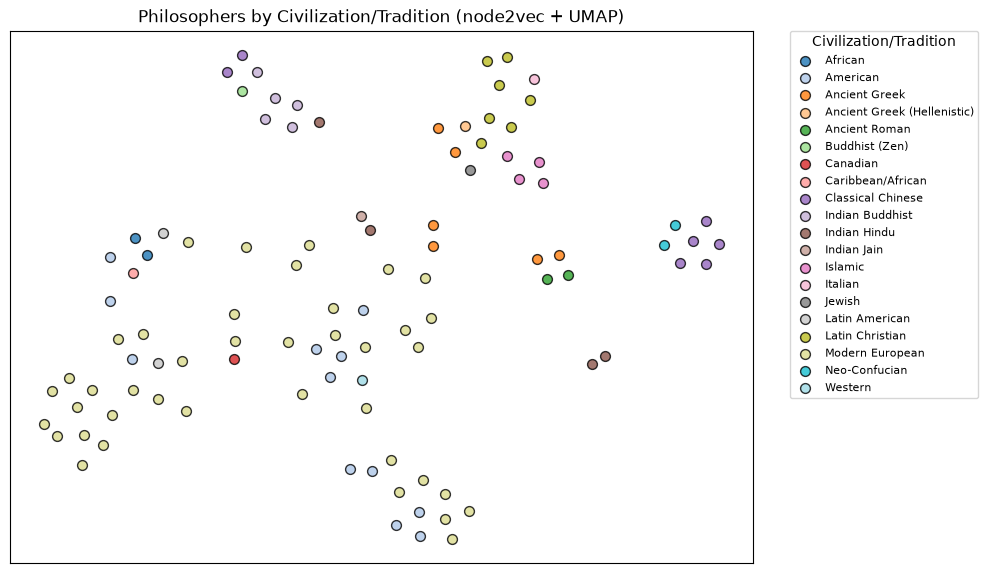

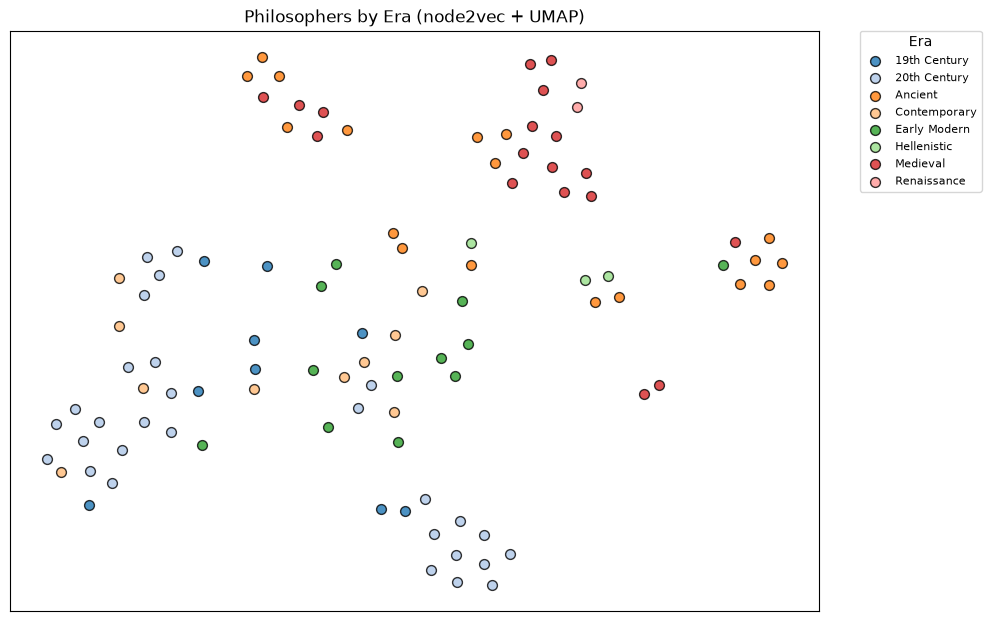

/var/folders/p8/bk0mdq9n0yjdt9g6tgs3h1rh0000gn/T/ipykernel_58063/2417051918.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


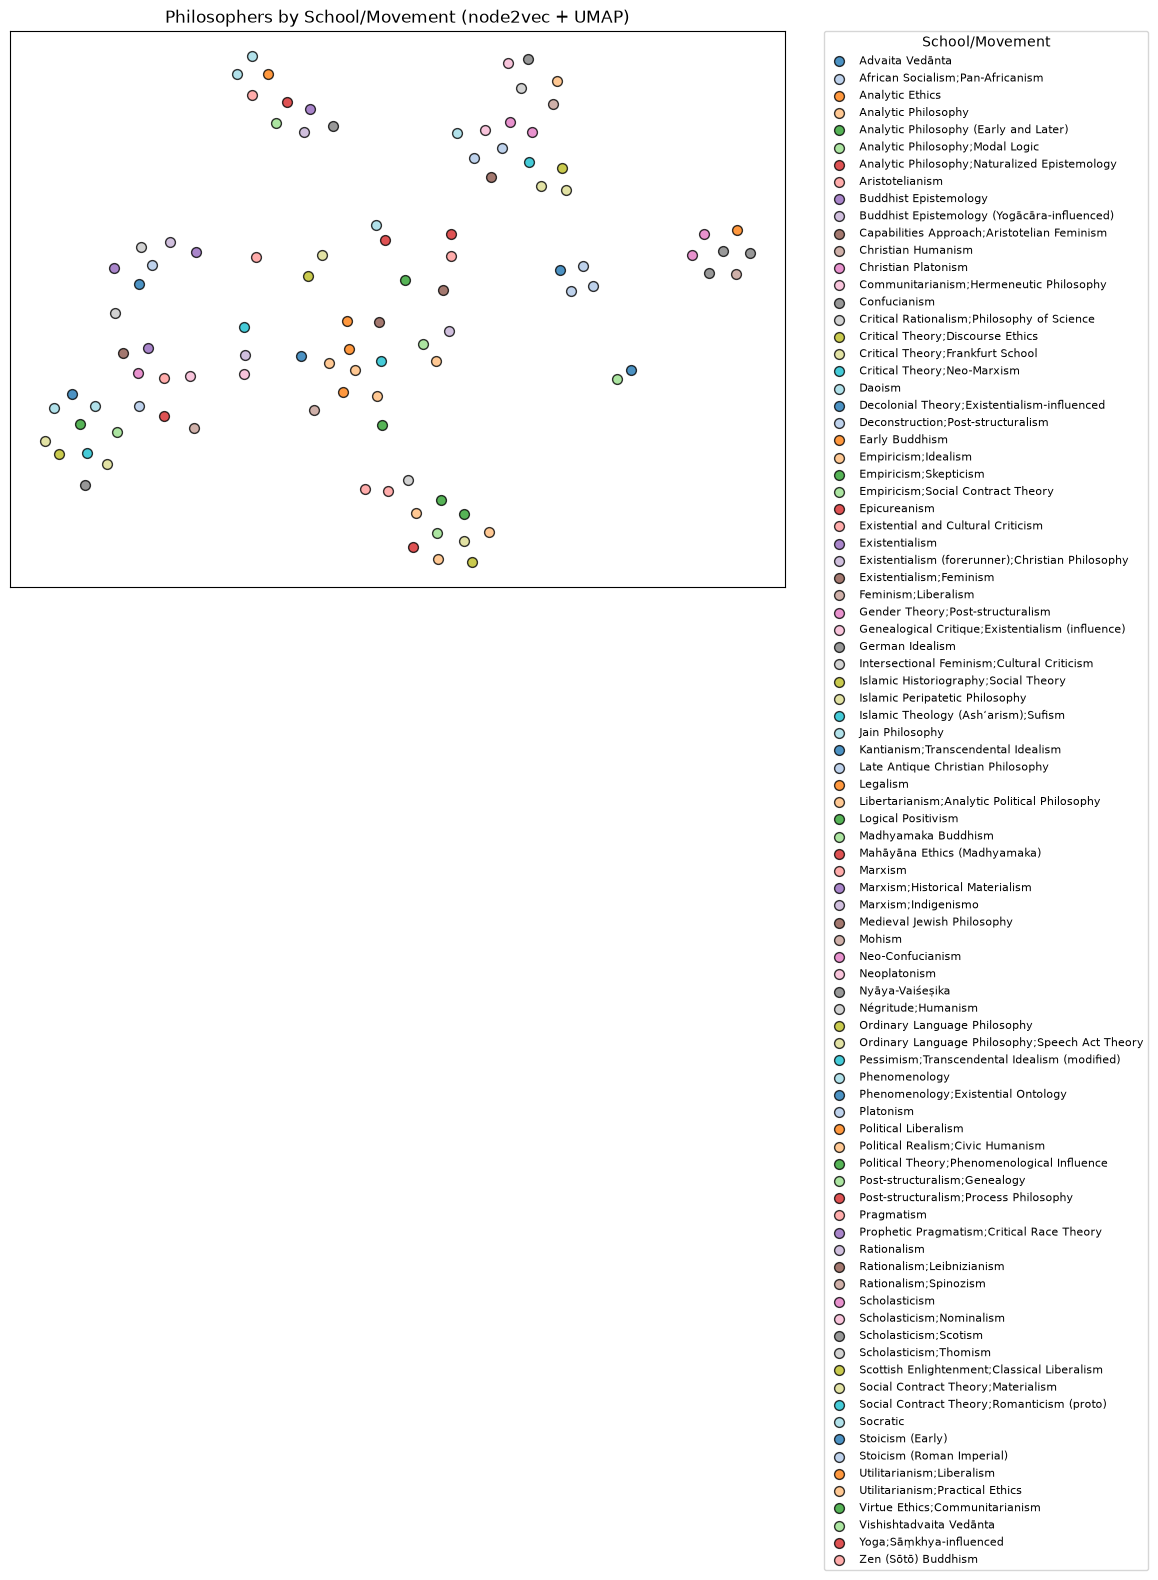

In [84]:
# ---------- 5. Helper: scatter plot with color by a field ----------

def plot_embedding(df, color_by="Civilization/Tradition", title=None, figsize=(10, 8)):
    """
    df: DataFrame with columns x, y, Name, and the color_by column.
    color_by: column name to color points by (e.g. 'Civilization/Tradition', 'Era', 'School/Movement')
    """
    plt.figure(figsize=figsize)

    # Handle missing values
    values = df[color_by].fillna("Unknown")
    unique_vals = sorted(values.unique())

    # Build a color map
    cmap = plt.get_cmap("tab20")
    color_map = {val: cmap(i % 20) for i, val in enumerate(unique_vals)}

    for val in unique_vals:
        subset = df[values == val]
        plt.scatter(
            subset["x"],
            subset["y"],
            c=[color_map[val]],
            label=val,
            alpha=0.8,
            edgecolor="k",
            s=50
        )

    plt.xticks([])
    plt.yticks([])
    plt.gca().set_aspect("equal", "box")
    plt.legend(
        title=color_by,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.,
        fontsize=8
    )
    plt.title(title or f"Philosopher Embedding (colored by {color_by})")
    plt.tight_layout()
    plt.show()

# ---------- 6. Example plots ----------

# Color by broad tradition
plot_embedding(coords_meta, color_by="Civilization/Tradition",
               title="Philosophers by Civilization/Tradition (node2vec + UMAP)")

# Color by era
plot_embedding(coords_meta, color_by="Era",
               title="Philosophers by Era (node2vec + UMAP)")

# Color by school/movement
plot_embedding(coords_meta, color_by="School/Movement",
               title="Philosophers by School/Movement (node2vec + UMAP)")

# Takeaways:

The graph ends with islands no matter what you do because some philosophers have few or no influence edges.  The lack of connection makes visualizing philosophers via graphs difficult.

Nevertheless, the best params seem to be Node2Vec with lower Q (towards DFS) and TSNE with 12 perplexity.  I'm saving those to start playing with the web UI!

In [65]:
coords_with_emb.to_csv('../data/node2vec_coords.csv', index=False)